In [1]:
import importlib

import ibis
import polars as pl
import pygraphviz as pgv
from ibis import deferred as _
from polars.testing import assert_frame_equal

import datasets
import datasets.fake
import pvm
import pvm.fields
import pvm.formulas
import pvm.pvm
from pvm.pvm import PVM

importlib.reload(pvm.formulas)
importlib.reload(pvm.pvm)
importlib.reload(datasets)
importlib.reload(pvm)
importlib.reload(pvm.fields)
importlib.reload(datasets.fake)
pass
pvm.__version__

from pvm.fields import CompositeRateField, Field, QuantityField, RateField

In [2]:
price = RateField(
    "unit_price",
    definition=(_.volume * _.unit_price).sum() / _.volume.sum(),
    components=[
        QuantityField(
            "price_in_lc",
            definition=(_.volume * _.price_in_lc).sum() / _.volume.sum(),
        ),
        RateField(
            "fx_rate",
            definition=(_.volume * _.fx_rate * _.price_in_lc).sum() / (_.price_in_lc * _.volume).sum(),
        ),
    ],
)

revenue_graph = Field(
    "revenue",
    definition=_.revenue.sum(),
    reconcile=False,
    components=[
        price,
        QuantityField(
            "volume",
            definition=_.volume.sum(),
        ),
        Field("flat_fee", definition=_.flat_fee.sum()),
    ],
)

cost_graph = Field(
    "cost",
    definition=-_.cost.sum(),
    reconcile=False,
    components=[
        QuantityField(
            "cost_volume",
            definition=_.volume.sum(),
            reconcile=False,
            components=[
                RateField(
                    "yield_rate",
                    definition=_.volume.sum() / _.raw_material.sum(),
                ),
                QuantityField(
                    "raw_material",
                    definition=_.raw_material.sum(),
                ),
            ],
        ),
        RateField(
            "unit_cost",
            definition=(-_.unit_cost * _.volume).sum() / _.volume.sum(),
        ),
    ],
)

In [3]:
r = revenue_graph.dot_representation()

print(r)
g = f"""
digraph foo {{
    node [margin=0.1 fontcolor=black fontsize=10 width=1 height=1 style=solid]
    {r}
}}
"""
print(g)

revenue [
            label=<
        <table border="0" cellborder="0" cellspacing="0" cellpadding="4">
			<tr> <td> <b>revenue (Field)</b> </td> </tr>
			<tr> <td> <b>Direct formula:</b> <i>_.revenue.sum()</i></td> </tr>
            <tr> <td> <b>Implied formula:</b> <i>unit_price * volume + (flat_fee)</i></td> </tr>
		</table>
        >
            shape=rectangle
        ]
        

digraph foo {
    node [margin=0.1 fontcolor=black fontsize=10 width=1 height=1 style=solid]
    revenue [
            label=<
        <table border="0" cellborder="0" cellspacing="0" cellpadding="4">
			<tr> <td> <b>revenue (Field)</b> </td> </tr>
			<tr> <td> <b>Direct formula:</b> <i>_.revenue.sum()</i></td> </tr>
            <tr> <td> <b>Implied formula:</b> <i>unit_price * volume + (flat_fee)</i></td> </tr>
		</table>
        >
            shape=rectangle
        ]
        
}



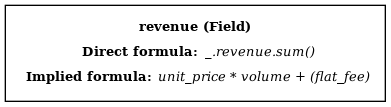

In [4]:
A = pgv.AGraph(string=g)
from IPython.display import Image

A.layout()
A.draw()
A.draw("/tmp/graph.png")
Image(filename="/tmp/graph.png")

In [5]:
print(revenue_graph.rate)
revenue_graph.components

RateField(name='unit_price', reconcile=False, components=[QuantityField(name='price_in_lc', reconcile=False, components=[], definition=((_.volume * _.price_in_lc).sum() / _.volume.sum()), dot_shape='cylinder'), RateField(name='fx_rate', reconcile=False, components=[], definition=(((_.volume * _.fx_rate) * _.price_in_lc).sum() / (_.price_in_lc * _.volume).sum()), dot_shape='ellipse')], definition=((_.volume * _.unit_price).sum() / _.volume.sum()), dot_shape='ellipse')


[RateField(name='unit_price', reconcile=False, components=[QuantityField(name='price_in_lc', reconcile=False, components=[], definition=((_.volume * _.price_in_lc).sum() / _.volume.sum()), dot_shape='cylinder'), RateField(name='fx_rate', reconcile=False, components=[], definition=(((_.volume * _.fx_rate) * _.price_in_lc).sum() / (_.price_in_lc * _.volume).sum()), dot_shape='ellipse')], definition=((_.volume * _.unit_price).sum() / _.volume.sum()), dot_shape='ellipse'),
 QuantityField(name='volume', reconcile=False, components=[], definition=_.volume.sum(), dot_shape='cylinder'),
 Field(name='flat_fee', reconcile=True, components=[], definition=_.flat_fee.sum(), dot_shape='rectangle')]

In [6]:
composite_rate = CompositeRateField(
    "unit_profit",
    components=[
        revenue_graph.rate,
        cost_graph.rate,
    ],
)

other_components = revenue_graph.other_components + cost_graph.other_components
components = [composite_rate, revenue_graph.quantity] + other_components

composite_profit_graph = Field(
    "profit",
    definition=_.revenue.sum() - _.cost.sum(),
    components=components,
)

In [ ]:
s = "(((_.volume * _.fx_rate) * _.price_in_lc).sum() / (_.price_in_lc * _.volume).sum())"


def recursive_len(x):
    if isinstance(x, list):
        return sum(recursive_len(y) for y in x)
    return len(x)


def parse(s):
    results = []
    g = ""
    i = 0
    while len(s) >= i:
        if s[i] == "(":
            if g:
                results.append(g)
            sub = parse(s[(i + 1) :])
            results.append(sub)
            i += recursive_len(sub)
        elif s[i] == ")":
            return results
        else:
            i += 1
            g += s[i]
    return results


print(parse(s))

# s[1:]

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fe2bee61400>>
Traceback (most recent call last):
  File "/home/aurimas/coding/pvm/.venv/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


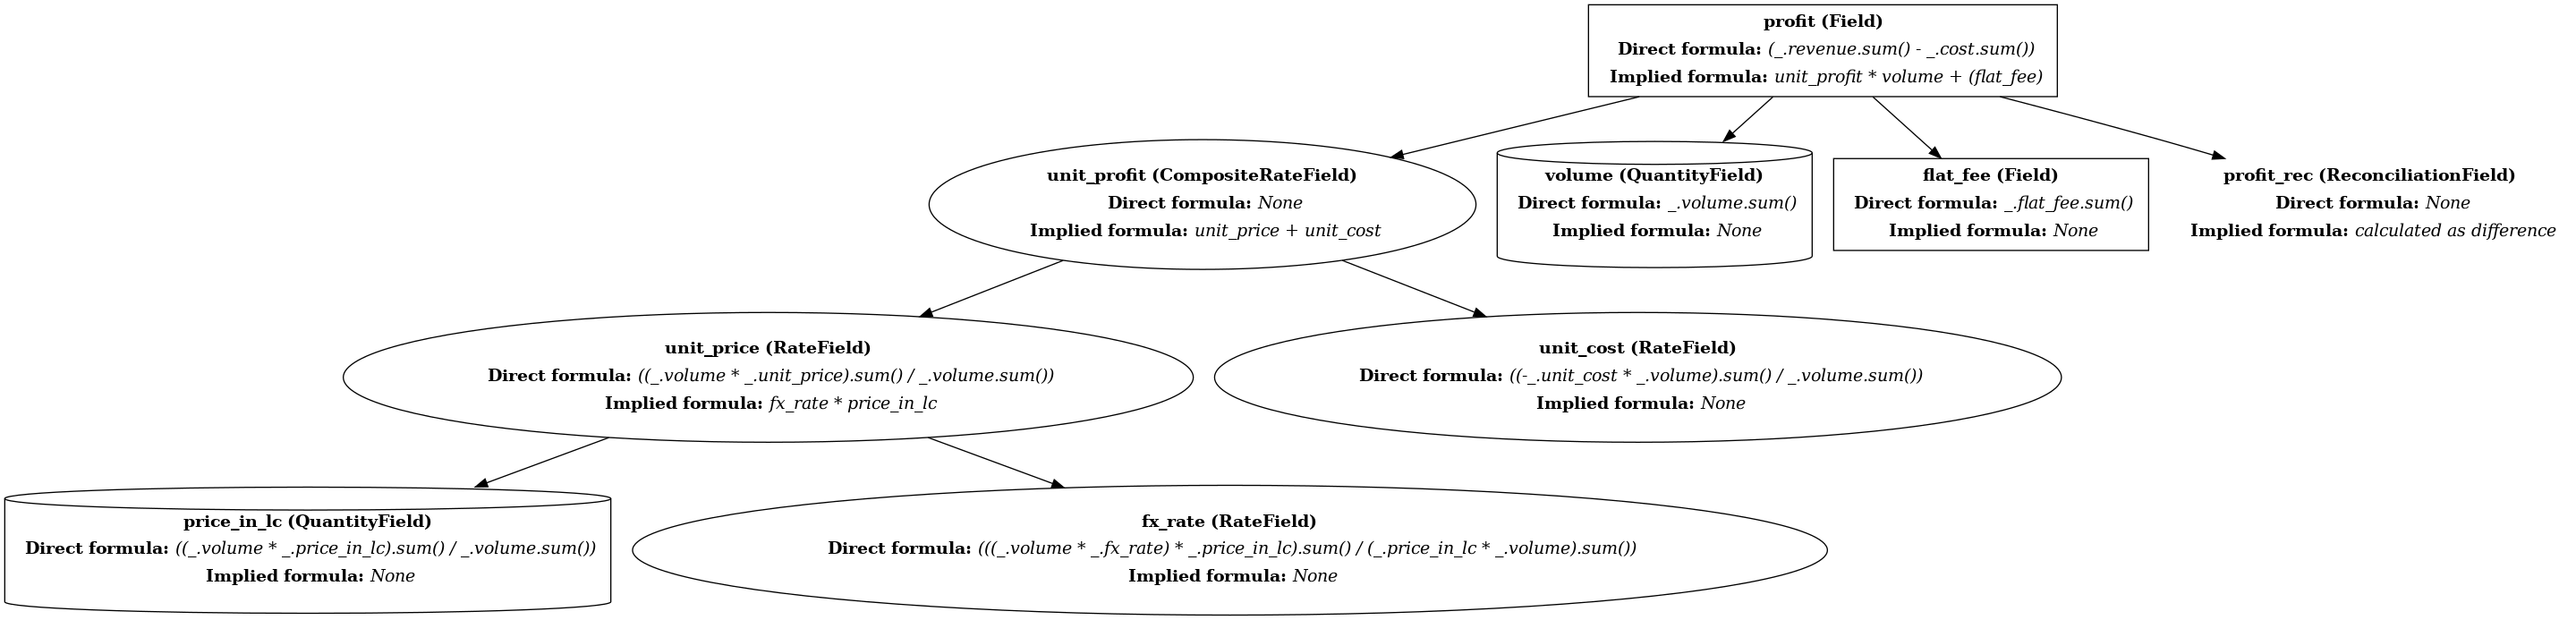

In [7]:
s = composite_profit_graph.to_dot_graph()
from IPython.display import Image

A = pgv.AGraph(string=s)
# A.layout()
A.draw("/tmp/graph.png", prog="dot")
Image(filename="/tmp/graph.png")

In [10]:
import pyperclip

pyperclip.copy(r)

In [81]:
composite_profit_graph.get_flattened_graph()

[Field(name='profit', type='simple', reconcile=True, components=[CompositeRateField(name='unit_profit', type='rate', reconcile=False, components=[RateField(name='unit_price', type='rate', reconcile=False, components=[QuantityField(name='price_in_lc', type='quantity', reconcile=False, components=[], definition=((_.volume * _.price_in_lc).sum() / _.volume.sum())), RateField(name='fx_rate', type='rate', reconcile=False, components=[], definition=(((_.volume * _.fx_rate) * _.price_in_lc).sum() / (_.price_in_lc * _.volume).sum()))], definition=((_.volume * _.unit_price).sum() / _.volume.sum())), RateField(name='unit_cost', type='rate', reconcile=False, components=[], definition=((-_.unit_cost * _.volume).sum() / _.volume.sum()))], definition=None), QuantityField(name='volume', type='quantity', reconcile=False, components=[], definition=_.volume.sum()), Field(name='flat_fee', type='simple', reconcile=True, components=[], definition=_.flat_fee.sum()), ReconciliationField(name='profit_rec', ty

In [7]:
d = {"1": {"2": None}, "2": {"1": None, "3": None}, "3": {"2": None}}

A = pgv.AGraph(d)

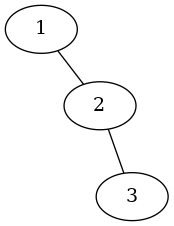

In [8]:
from IPython.display import Image

A.layout()
A.draw()
A.draw("/tmp/graph.png")
Image(filename="/tmp/graph.png")

In [9]:
con = ibis.polars.connect({"sales": datasets.sales.raw})
sales = con.table("sales")

obj = PVM().set_data(sales).set_periods(_.year, ["2020", "2021"]).set_hierarchy([_.country, _.sku])

obj.set_graph(composite_profit_graph)

In [10]:
obj.calculate_effects().to_polars()

country,sku,profit_2020,unit_profit_2020,unit_price_2020,price_in_lc_2020,fx_rate_2020,unit_cost_2020,volume_2020,flat_fee_2020,profit_rec_2020,profit_2021,unit_profit_2021,unit_price_2021,price_in_lc_2021,fx_rate_2021,unit_cost_2021,volume_2021,flat_fee_2021,profit_rec_2021,profit__change__2020,unit_profit__change__2020,unit_price__change__2020,price_in_lc__change__2020,fx_rate__change__2020,unit_cost__change__2020,volume__change__2020,flat_fee__change__2020,profit_rec__change__2020,volume__effect__2020,unit_profit__effect__2020,unit_price__effect__2020,unit_cost__effect__2020,price_in_lc__effect__2020,fx_rate__effect__2020,flat_fee__effect__2020,profit_rec__effect__2020
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Bouvet Island (Bouvetoya)""","""SKU3""",8681.128492,22.349748,78.619419,60.60087,1.297332,-56.269671,387.563455,19.182827,-0.000001,5693.147644,23.653094,75.726279,62.631814,1.2090705,-52.073185,241.714897,-24.157541,-0.000001,-2987.980848,1.303346,-2.89314,2.030944,-0.088261,4.196486,-145.848558,-43.340368,3.1207e-7,-3259.678552,315.038071,-699.315005,1014.353076,636.872272,-1336.187339,-43.340368,3.1207e-7
"""Burundi""","""SKU2""",9900.534715,16.15903,79.940015,69.547897,1.1494239,-63.780984,612.693618,0.0,0.000002,7918.712281,17.81292,80.703874,70.840422,1.139235,-62.890955,443.963078,10.433554,8.6293e-7,-1981.822435,1.65389,0.76386,1.292525,-0.010189,0.89003,-168.73054,10.433554,-8.4125e-7,-2726.521899,734.265912,339.125553,395.140359,659.577949,-320.452299,10.433554,-8.4125e-7
"""Bouvet Island (Bouvetoya)""","""SKU4""",1193.389592,4.297,17.202885,13.260208,1.297332,-12.905885,277.72621,0.0,-6.4433e-7,2321.582824,3.988544,15.927495,13.173339,1.2090705,-11.938951,582.062675,0.0,7.5105e-7,1128.193231,-0.308456,-1.27539,-0.086869,-0.088261,0.966934,304.336465,0.0,0.000001,1307.733864,-179.540634,-742.357022,562.816388,-65.597265,-676.75979,0.0,0.000001
"""Saint Vincent and the Grenadin…","""SKU1""",20638.218236,31.703204,96.690872,107.9243,0.895914,-64.987667,650.982093,0.0,0.000002,10291.96468,30.488615,96.563636,102.226497,0.944605,-66.075022,337.567476,0.0,-1.2882e-7,-10346.253556,-1.21459,-0.127235,-5.697803,0.048691,-1.087355,-313.414616,0.0,-0.000002,-9936.247594,-410.005959,-42.950437,-367.055523,-1723.194448,1680.243882,0.0,-0.000002
"""Ecuador""","""SKU4""",980.684719,2.684124,15.033763,10.917484,1.377035,-12.349639,376.515105,-29.928505,-7.6989e-7,1679.572809,3.586422,20.195195,14.661295,1.37745,-16.608772,468.314291,0.0,-5.3291e-8,698.88809,0.902298,5.161432,3.743811,0.000414,-4.259134,91.799187,29.928505,7.1660e-7,246.400399,422.559185,2417.17229,-1994.613105,2414.329072,2.843181,29.928505,7.1660e-7
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Ecuador""","""SKU1""",10251.277479,29.820053,95.434063,69.303998,1.377035,-65.61401,344.010657,-7.13868,-0.000002,18364.743411,32.167173,97.475661,70.765322,1.37745,-65.308488,571.759835,-27.154195,-4.2528e-8,8113.465931,2.34712,2.041598,1.461323,0.000414,0.305522,227.749178,-20.015515,0.000001,6791.492658,1341.988786,1167.303588,174.685199,1150.548965,16.7544,-20.015515,0.000001
"""Bouvet Island (Bouvetoya)""","""SKU1""",11849.789756,32.844586,97.729329,75.331038,1.297332,-64.884743,360.696298,2.8691221,-1.7909e-7,8568.165422,31.933646,94.537847,78.190517,1.2090705,-62.604202,268.311532,0.0,0.000002,-3281.624335,-0.91094,-3.191482,2.859479,-0.088261,2.280542,-92.384766,-2.869122,0.000002,-3034.339397,-244.415818,-856.311408,611.89559,995.353285,-1851.664778,-2.869122,0.000002
"""Ecuador""","""SKU0""",1205.76046,3.905395,12.948355,9.403066,1.377035,-9.04296,308.74223,0.0,-3.8318e-7,446.491383,1.88611,11.902419,8.640911,1.37745,-10.016309,236.72605,0.0,9.1017e-7,-759.269077,-2.019285,-1.045936,-0.762155,0.000414,-0.973349,-72.01618,0.0,0.000001,-281.251654,-478.017425,-247.600378,-230.417047,-248.447422,0.847033,0.0,0.000001


In [11]:
assert_frame_equal(
    obj.calculate_effects().to_polars().sort("customer", "sku"),
    datasets.sales.cost_effects_by_customer_sku.sort("customer", "sku"),
    check_column_order=False,
    check_row_order=True,
    check_dtypes=False,
    atol=1e-2,
)

ColumnNotFoundError: "customer" not found

In [5]:
unbound_table = ibis.table(sales.schema())
ibis.to_sql(obj.set_data(unbound_table).calculate_effects())

```sql
SELECT
  "t3"."customer",
  "t3"."sku",
  "t3"."cost_2020",
  "t3"."cost_volume_2020",
  "t3"."yield_rate_2020",
  "t3"."raw_material_2020",
  "t3"."unit_cost_2020",
  "t3"."cost_2021",
  "t3"."cost_volume_2021",
  "t3"."yield_rate_2021",
  "t3"."raw_material_2021",
  "t3"."unit_cost_2021",
  "t3"."cost_2021" - "t3"."cost_2020" AS "cost__change__2020",
  "t3"."cost_volume_2021" - "t3"."cost_volume_2020" AS "cost_volume__change__2020",
  "t3"."yield_rate_2021" - "t3"."yield_rate_2020" AS "yield_rate__change__2020",
  "t3"."raw_material_2021" - "t3"."raw_material_2020" AS "raw_material__change__2020",
  "t3"."unit_cost_2021" - "t3"."unit_cost_2020" AS "unit_cost__change__2020",
  CASE
    WHEN (
      COALESCE("t3"."cost_volume_2020", 0) <> 0
    )
    AND (
      COALESCE("t3"."cost_volume_2021", 0) <> 0
    )
    THEN (
      "t3"."cost_volume_2021" - "t3"."cost_volume_2020"
    ) * "t3"."unit_cost_2020" * 1.0
    ELSE (
      (
        "t3"."cost_volume_2021" * "t3"."unit_cost_2021"
      ) - (
        "t3"."cost_volume_2020" * "t3"."unit_cost_2020"
      )
    ) * 1.0
  END AS "cost_volume__effect__2020",
  CASE
    WHEN (
      COALESCE("t3"."cost_volume_2020", 0) <> 0
    )
    AND (
      COALESCE("t3"."cost_volume_2021", 0) <> 0
    )
    THEN (
      "t3"."unit_cost_2021" - "t3"."unit_cost_2020"
    ) * "t3"."cost_volume_2021" * 1.0
    ELSE 0
  END AS "unit_cost__effect__2020",
  CASE
    WHEN (
      COALESCE("t3"."raw_material_2020", 0) <> 0
    )
    AND (
      COALESCE("t3"."raw_material_2021", 0) <> 0
    )
    THEN (
      "t3"."raw_material_2021" - "t3"."raw_material_2020"
    ) * "t3"."yield_rate_2020" * CASE
      WHEN (
        COALESCE("t3"."cost_volume_2020", 0) <> 0
      )
      AND (
        COALESCE("t3"."cost_volume_2021", 0) <> 0
      )
      THEN "t3"."unit_cost_2020" * 1.0
      ELSE 1
    END
    ELSE (
      (
        "t3"."raw_material_2021" * "t3"."yield_rate_2021"
      ) - (
        "t3"."raw_material_2020" * "t3"."yield_rate_2020"
      )
    ) * CASE
      WHEN (
        COALESCE("t3"."cost_volume_2020", 0) <> 0
      )
      AND (
        COALESCE("t3"."cost_volume_2021", 0) <> 0
      )
      THEN "t3"."unit_cost_2020" * 1.0
      ELSE 1
    END
  END AS "raw_material__effect__2020",
  CASE
    WHEN (
      COALESCE("t3"."raw_material_2020", 0) <> 0
    )
    AND (
      COALESCE("t3"."raw_material_2021", 0) <> 0
    )
    THEN (
      "t3"."yield_rate_2021" - "t3"."yield_rate_2020"
    ) * "t3"."raw_material_2021" * CASE
      WHEN (
        COALESCE("t3"."cost_volume_2020", 0) <> 0
      )
      AND (
        COALESCE("t3"."cost_volume_2021", 0) <> 0
      )
      THEN "t3"."unit_cost_2020" * 1.0
      ELSE 1
    END
    ELSE 0
  END AS "yield_rate__effect__2020"
FROM (
  SELECT
    "t2"."customer",
    "t2"."sku",
    COALESCE(SUM("t2"."cost") FILTER(WHERE
      "t2"."__period__" = '2020'), 0) AS "cost_2020",
    COALESCE(SUM("t2"."cost_volume") FILTER(WHERE
      "t2"."__period__" = '2020'), 0) AS "cost_volume_2020",
    COALESCE(SUM("t2"."yield_rate") FILTER(WHERE
      "t2"."__period__" = '2020'), 0) AS "yield_rate_2020",
    COALESCE(SUM("t2"."raw_material") FILTER(WHERE
      "t2"."__period__" = '2020'), 0) AS "raw_material_2020",
    COALESCE(SUM("t2"."unit_cost") FILTER(WHERE
      "t2"."__period__" = '2020'), 0) AS "unit_cost_2020",
    COALESCE(SUM("t2"."cost") FILTER(WHERE
      "t2"."__period__" = '2021'), 0) AS "cost_2021",
    COALESCE(SUM("t2"."cost_volume") FILTER(WHERE
      "t2"."__period__" = '2021'), 0) AS "cost_volume_2021",
    COALESCE(SUM("t2"."yield_rate") FILTER(WHERE
      "t2"."__period__" = '2021'), 0) AS "yield_rate_2021",
    COALESCE(SUM("t2"."raw_material") FILTER(WHERE
      "t2"."__period__" = '2021'), 0) AS "raw_material_2021",
    COALESCE(SUM("t2"."unit_cost") FILTER(WHERE
      "t2"."__period__" = '2021'), 0) AS "unit_cost_2021"
  FROM (
    SELECT
      "t1"."customer",
      "t1"."sku",
      CAST("t1"."year" AS TEXT) AS "__period__",
      -(
        SUM("t1"."cost")
      ) AS "cost",
      SUM("t1"."volume") AS "cost_volume",
      SUM("t1"."volume") / SUM("t1"."raw_material") AS "yield_rate",
      SUM("t1"."raw_material") AS "raw_material",
      SUM(-(
        "t1"."unit_cost"
      ) * "t1"."volume") / SUM("t1"."volume") AS "unit_cost"
    FROM (
      SELECT
        *
      FROM "unbound_table_0" AS "t0"
      WHERE
        CAST("t0"."year" AS TEXT) IN ('2020', '2021')
    ) AS "t1"
    GROUP BY
      1,
      2,
      3
  ) AS "t2"
  GROUP BY
    1,
    2
) AS "t3"
```

In [ ]:
obj.calculate_effects().to_polars().select(
    "sku",
    "country",
    "unit_price__effect__2020",
    "price_in_lc__effect__2020",
    "fx_rate__effect__2020",
).with_columns(
    (pl.col("unit_price__effect__2020") - pl.col("price_in_lc__effect__2020") - pl.col("fx_rate__effect__2020")).alias(
        "diff",
    ),
).sort(["country", "sku"])

sku,country,unit_price__effect__2020,price_in_lc__effect__2020,fx_rate__effect__2020,diff
str,str,f64,f64,f64,f64
"""SKU0""","""Bouvet Island (Bouvetoya)""",-245.058235,221.171414,-465.975594,-0.254054
"""SKU1""","""Bouvet Island (Bouvetoya)""",775.666603,3633.445595,-2856.300861,-1.478131
"""SKU2""","""Bouvet Island (Bouvetoya)""",1488.422966,4013.257933,-2523.560357,-1.27461
"""SKU3""","""Bouvet Island (Bouvetoya)""",-1632.4751,2424.875364,-4055.173563,-2.176901
"""SKU4""","""Bouvet Island (Bouvetoya)""",-1822.414223,-1480.970039,-341.218744,-0.225439
…,…,…,…,…,…
"""SKU0""","""Saint Vincent and the Grenadin…",-1.24942,509.947018,-511.49295,0.296511
"""SKU1""","""Saint Vincent and the Grenadin…",-1233.187334,2225.256196,-3460.371041,1.927511
"""SKU2""","""Saint Vincent and the Grenadin…",-244.626223,1678.173782,-1923.883343,1.083338
